# Load package

In [1]:
import scimap as sm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

import scanpy as sc

Running SCIMAP  2.2.11


In [2]:
from aicsimageio import AICSImage
import tifffile
import numpy as np

27-Jun-25 17:59:01 - bfio.backends - WARNING  - Java backend is not available. This could be due to a missing dependency (jpype).


# Load data

In [3]:
df = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv', index_col=0)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_69950/188704042.py:1: DtypeWarning:

Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.



In [13]:
df.columns

Index(['S9.6', 'HER3', 'panCK', 'SMA', 'CD45', 'Ki67_2', 'CD4', 'FOXP3',
       'CD8a', 'CD11b', 'CD68', 'CD206', 'H2ax', 'Vimentin', 'H3K27me3',
       'E.Cadherin', 'GCLC', 'TXNRD1', 'NQO1', 'pERK', 'TXN', 'pSTAT3',
       'pS6_235', 'pRB', 'GLUT1', 'X_centroid', 'Y_centroid', 'imageid',
       'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage',
       'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI',
       'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1',
       'NQO1_GCLC_VIM', 'celltype_2', 'celltype_1', 'Tumor_state', 'GCLC_VIM',
       'CellCategory', 'SC45px_neigh_kmeans_10', 'RCNs'],
      dtype='object')

In [16]:
df_sub = df[['X_centroid', 'Y_centroid', 'imageid', 'core_imageid', 'GCLC_VIM', 'RCNs']].copy()
df_sub = df_sub[df_sub['imageid'] == 'INF2']
df_sub['CellID'] = df_sub.index.astype(str)
df_sub.to_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/RCNs_INF2.csv', index=False)

In [20]:
image_path = '/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv'
# Convert the data to scimap format
adata = sm.pp.mcmicro_to_scimap(image_path, 
                                remove_dna=False, remove_string_from_name=None, log=False, drop_markers=None,
                                random_sample=None, unique_CellId=True, CellId='CellID', split='X_centroid',
                                custom_imageid=None, min_cells=None, output_dir=None)
adata.obsm['spatial'] = np.array(adata.obs[['Y_centroid', 'X_centroid']])
adata

Loading Data_AllMarkers_filtered_RCNs.csv


/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/scimap/preprocessing/mcmicro_to_scimap.py:106: DtypeWarning:

Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.



AnnData object with n_obs × n_vars = 3681772 × 25
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'celltype_2', 'celltype_1', 'Tumor_state', 'GCLC_VIM', 'CellCategory', 'SC45px_neigh_kmeans_10', 'RCNs', 'CellID', 'imageid'
    uns: 'all_markers'
    obsm: 'spatial'

In [33]:
adata_sub = adata[adata.obs['imageid'] == 'INF2'].copy()
adata_sub.obs = adata_sub.obs[['X_centroid', 'Y_centroid', 'imageid', 'core_imageid', 'GCLC_VIM', 'RCNs', 'CellID']]

In [34]:
adata_sub.obs

,X_centroid,Y_centroid,imageid,core_imageid,GCLC_VIM,RCNs,CellID
INF2_1000,24342.76,1470.506,INF2,core42_INF2,Treg,RCN6,1000
INF2_1001,24386.07,1469.750,INF2,core42_INF2,CD4.T.cells,RCN6,1001
INF2_1002,24330.01,1472.162,INF2,core42_INF2,Treg,RCN6,1002
INF2_1003,24424.06,1473.431,INF2,core42_INF2,Treg,RCN6,1003
INF2_1004,24454.99,1470.632,INF2,core42_INF2,Other.Immune,RCN6,1004
...,...,...,...,...,...,...,...
INF2_99699,41337.66,4310.933,INF2,core14_INF2,Tumor.GCLC-VIM-,RCN1,99699
INF2_997,24560.77,1469.787,INF2,core42_INF2,Treg,RCN6,997
INF2_99700,41317.93,4315.393,INF2,core14_INF2,Tumor.GCLC-VIM-,RCN1,99700
INF2_998,24445.84,1467.636,INF2,core42_INF2,CD4.T.cells,RCN6,998


In [35]:
adata_sub.write('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/RCNs_INF2.h5ad')

In [36]:
adata_sub

AnnData object with n_obs × n_vars = 327393 × 25
    obs: 'X_centroid', 'Y_centroid', 'imageid', 'core_imageid', 'GCLC_VIM', 'RCNs', 'CellID'
    uns: 'all_markers'
    obsm: 'spatial'

# RCN distribution

In [34]:
data = adata.obs.copy()
data = data[['celltype_1', 'RCNs', 'Annotation', 'CellID', 'imageid', 'core_imageid', 'patient_id_AB19_1654']].copy()

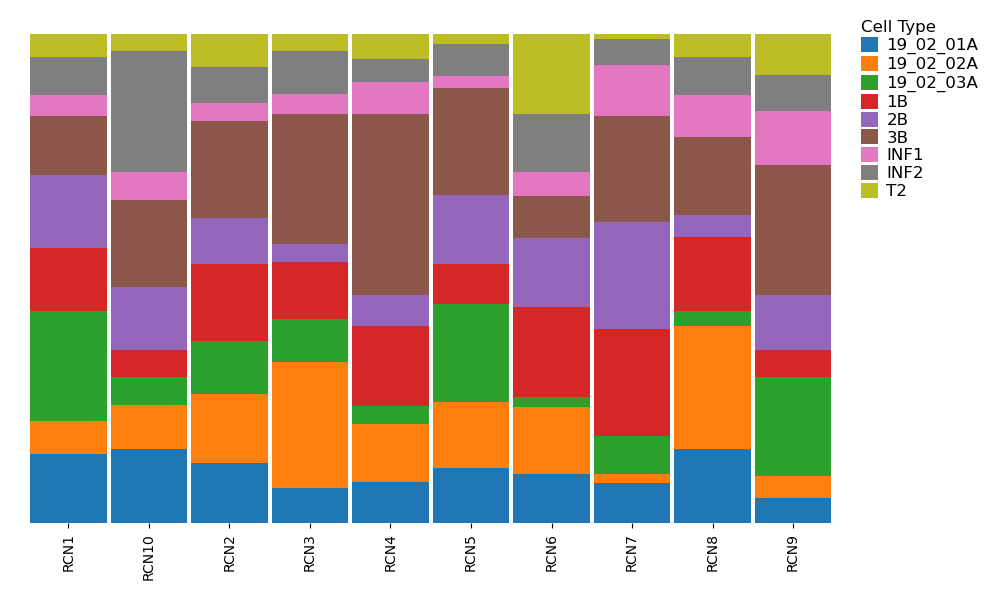

In [14]:

df = data[['RCNs', 'imageid']]

count_df = df.groupby(['RCNs', 'imageid']).size().unstack(fill_value=0)
total_counts = df['RCNs'].value_counts().sort_index()
percent_df = count_df.div(total_counts, axis=0) * 100

# Set the style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
percent_df.plot(kind='bar', stacked=True, 
                ax=ax, width=0.95, edgecolor='none')

# Add the legend outside the plot
legend = plt.legend(title='Cell Type', bbox_to_anchor=(1.0, 1), 
           loc='upper left', fontsize=12,
           frameon=False,
           handleheight=1.0, handlelength=1.0,
           handletextpad=0.5, labelspacing=0.1,
           borderpad=0.1)
#legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(12)  # Increase title font size
legend._legend_box.align = "left"

for spine in ax.spines.values():
    spine.set_visible(False)
plt.yticks([]) 

# Add labels and title
plt.title('', fontsize=12)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
plt.xticks(rotation=90)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

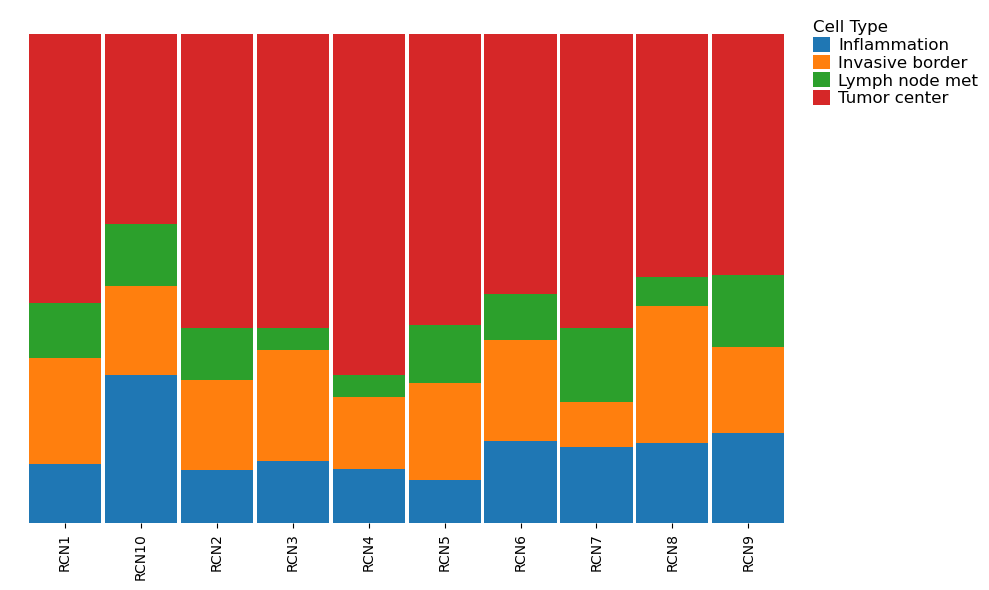

In [36]:

df = data[['RCNs', 'Annotation']]

count_df = df.groupby(['RCNs', 'Annotation']).size().unstack(fill_value=0)
total_counts = df['RCNs'].value_counts().sort_index()
percent_df = count_df.div(total_counts, axis=0) * 100

# Set the style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
percent_df.plot(kind='bar', stacked=True, 
                ax=ax, width=0.95, edgecolor='none')

# Add the legend outside the plot
legend = plt.legend(title='Cell Type', bbox_to_anchor=(1.0, 1), 
           loc='upper left', fontsize=12,
           frameon=False,
           handleheight=1.0, handlelength=1.0,
           handletextpad=0.5, labelspacing=0.1,
           borderpad=0.1)
#legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(12)  # Increase title font size
legend._legend_box.align = "left"

for spine in ax.spines.values():
    spine.set_visible(False)
plt.yticks([]) 

# Add labels and title
plt.title('', fontsize=12)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
plt.xticks(rotation=90)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# spatial plot

In [49]:
adata_sub = adata[adata.obs['imageid'] == 'INF2']

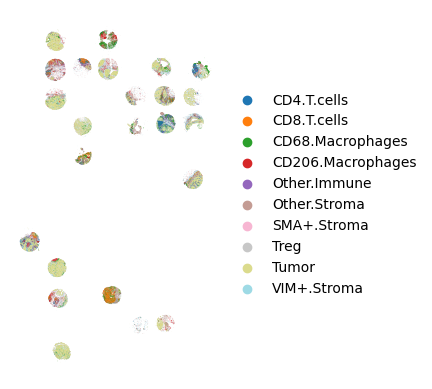

In [42]:
sc.pl.spatial(adata_sub, color='celltype_1', spot_size=30, title='', frameon=False, show=True, palette='tab20')

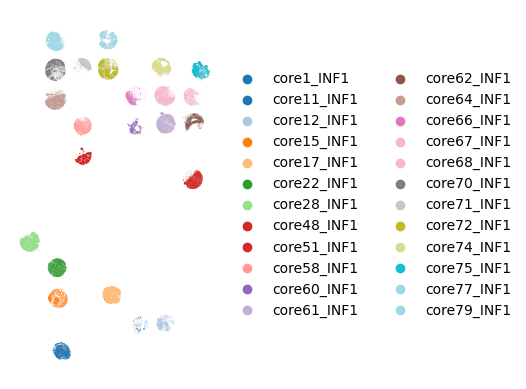

In [46]:
sc.pl.spatial(adata_sub, color='core_imageid', spot_size=30, title='', frameon=False, show=True, palette='tab20')

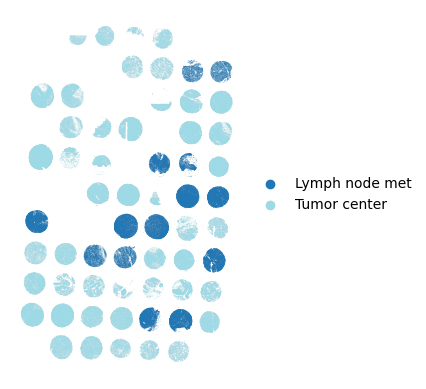

In [37]:
sc.pl.spatial(adata_sub, color='Annotation', spot_size=30, title='', frameon=False, show=True, palette='tab20', save='Annotation_3B.pdf')

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initi

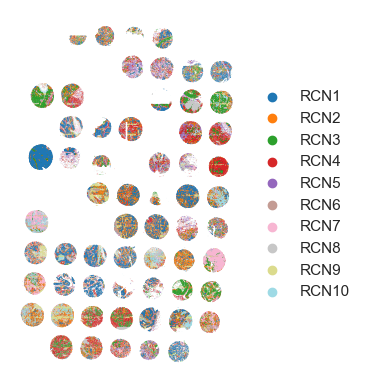

In [48]:
sc.pl.spatial(adata_sub, color='RCNs', spot_size=30, title='', frameon=False, show=True, palette='tab20', save='RCNs_3B.pdf')

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initi

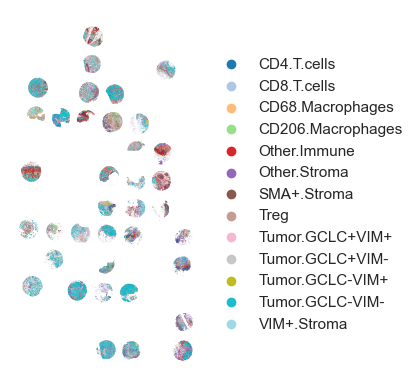

In [50]:
sc.pl.spatial(adata_sub, color='GCLC_VIM', spot_size=30, title='', frameon=False, show=True, palette='tab20', save='GCLC_VIM_INF2.pdf')

In [ ]:
# Get unique imageids
unique_imageids = adata.obs['imageid'].unique()

# Loop through each imageid
for img_id in unique_imageids:
    # Filter data for current imageid
    adata_sub = adata[adata.obs['imageid'] == img_id]
    
    # Create spatial plots
    sc.pl.spatial(adata_sub, color='Annotation', spot_size=30, title='', 
                 frameon=False, show=True, palette='tab20', save=f'Annotation_{img_id}.pdf')
    
    sc.pl.spatial(adata_sub, color='RCNs', spot_size=30, title='', 
                 frameon=False, show=True, palette='tab20', save=f'RCNs_{img_id}.pdf')
    
    sc.pl.spatial(adata_sub, color='patient_id_AB19_1654', spot_size=30, title='',
                  frameon=False, show=True, palette='tab20', save=f'Patient_{img_id}.pdf')
    
    sc.pl.spatial(adata_sub, color='core_imageid', spot_size=30, title='',
                  frameon=False, show=True, palette='tab20', save=f'Core_{img_id}.pdf')
    
    sc.pl.spatial(adata_sub, color='celltype_1', spot_size=30, title='',
                  frameon=False, show=True, palette='tab20', save=f'CellType_{img_id}.pdf')

# TMA

## Napari

In [44]:
data = pd.read_csv('/Volumes/group/h345/afarkkilab/Data/17_Auria_TMA/for_Silja/data_06052024_smaller_subset.csv')

In [45]:
data

,CellID,Vimentin,GCLC,X_centroid,Y_centroid,imageid,celltype,core_imageid
0,1,0.035191,0.170813,2027.642,1011.2380,19_02_02A,Other,core77_19_02_02A
1,1,0.747758,0.383274,6640.336,1014.6120,M1,Other,core7_M1
2,10,0.089693,0.288927,5871.136,777.1124,19_02_01A,Tumor,core77_19_02_01A
3,10,0.106524,0.392473,1999.424,1195.5040,19_02_02A,CD68.Macrophages,core77_19_02_02A
4,10,0.820906,0.574350,6745.534,1036.0190,M1,CD4.T.cells,core7_M1
...,...,...,...,...,...,...,...,...
4150338,99999,0.584573,0.526600,8371.249,6579.8230,2B,CD4.T.cells,core71_2B
4150339,99999,0.149835,0.288315,20828.410,4477.0180,3B,Tumor,core42_3B
4150340,99999,0.181422,0.463759,36941.910,6450.2230,INF1,Tumor,core22_INF1
4150341,99999,0.347549,0.431666,19173.260,10346.5900,INF3,CD4.T.cells,core2_INF3


In [47]:
cdata = sm.pp.mcmicro_to_scimap("/Volumes/group/h345/afarkkilab/Data/17_Auria_TMA/for_Silja/data_06052024_smaller_subset.csv",
                                CellId = "CellID", split="X_centroid", log=False)

Loading data_06052024_smaller_subset.csv


In [53]:
adata_sub = adata[adata.obs['imageid'] == 'INF2']

In [54]:
channel_list = ['DNA1', 'H3.1', 'pRPA32', 'S9.6', 'DNA2', 'Ki67_1', 'TNFR1', 'HER3', 'DNA3', 'panCK', 'SMA', 
 'CD45', 'Ki67_2', 'DNA4', 'CD4', 'FOXP3', 'CD8a','DNA5', 'CD11b', 'CD68', 'CD206', 'DNA6', 'PCNA',
 'ER', 'HER2', 'DNA7', 'EGFR', 'PR', 'H2ax', 'DNA8', 'Vimentin', 'H3K27me3', 'E.Cadherin', 'DNA9',
 'GCLC', 'TXNRD1', 'NQO1', 'DNA10', 'PERK', 'TXN', 'pSTAT3', 'DNA11', 'pS6_235', 'pRB', 'GLUT1']

In [ ]:
# pass in the path to the image
image_path = '/Volumes/group/h345/afarkkilab/Data/17_Auria_TMA/registration/ABTMA00-2D02_INF2.ome.tif'

# view in napari
sm.pl.image_viewer(image_path=image_path, 
                   adata=adata_sub,
                   channel_names=channel_list,
                   overlay='RCNs', 
                   point_size=10,
                   point_color='white')

## Voronoi

In [4]:
adata_sub = adata[adata.obs['imageid'] == 'INF1']

In [5]:
adata_sub_core = adata_sub[adata_sub.obs['core_imageid'] == 'core75_INF1']

In [8]:
rcn_colors = {
    'RCN1': '#1f77b4',  
    'RCN2': '#ff7f0e', 
    'RCN3': '#2ca02c', 
    'RCN4': '#d62728',  
    'RCN5': '#9467bd', 
    'RCN6': '#8c564b', 
    'RCN7': '#e377c2', 
    'RCN8': '#7f7f7f', 
    'RCN9': '#bcbd22', 
    'RCN10': '#17becf'
}


In [7]:
adata_sub_core

View of AnnData object with n_obs × n_vars = 10191 × 25
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'celltype_2', 'celltype_1', 'Tumor_state', 'GCLC_VIM', 'CellCategory', 'SC45px_neigh_kmeans_10', 'RCNs', 'CellID', 'imageid'
    uns: 'all_markers'
    obsm: 'spatial'

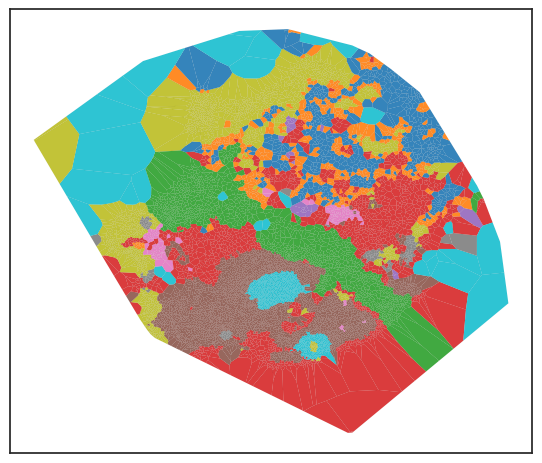

In [8]:
sm.pl.voronoi(adata_sub_core, imageid = "imageid", subset=None,  colors = rcn_colors, figsize=(30, 30),
              x_coordinate='X_centroid', y_coordinate='Y_centroid', color_by='RCNs',
              voronoi_edge_color = 'black',voronoi_line_width = 0.01, voronoi_alpha = 0.9, overlay_points=None,
              plot_legend=True, legend_size=6, flip_y=False)

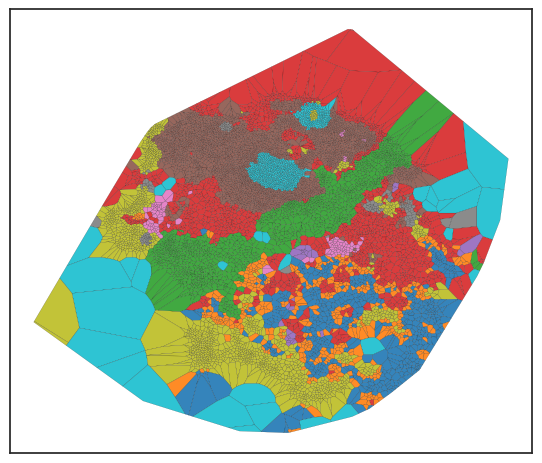

In [12]:
sm.pl.voronoi(adata_sub_core, imageid = "imageid", subset=None,  colors = rcn_colors, figsize=(30, 30),
              x_coordinate='X_centroid', y_coordinate='Y_centroid', color_by='RCNs',
              voronoi_edge_color = 'black',voronoi_line_width = 0.1, voronoi_alpha = 0.9, overlay_points=None,
              plot_legend=True, legend_size=6, flip_y=True)

In [38]:
legend_elements = [
    mpatches.Patch(facecolor=color, edgecolor=None, label=label)
    for label, color in rcn_colors.items()
]

fig, ax = plt.subplots(figsize=(3, 5))
ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=False,
    fontsize=8,
)
ax.axis('off')

fig.savefig("/Users/wenqchen/Desktop/Projects/Auria/Plots/Voronoi/RCNs_legend.pdf", bbox_inches='tight')
plt.close(fig)

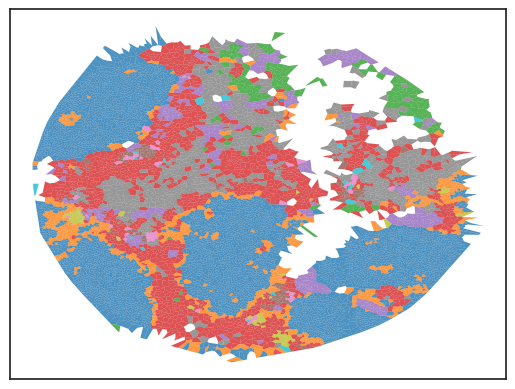

In [ ]:
core_imageid = 'core72_INF1'
sm.pl.voronoi(adata_sub,
              color_by='RCNs', colors=rcn_colors,
              imageid='core_imageid',
              subset=core_imageid,
              x_coordinate='Y_centroid', y_coordinate='X_centroid',
              flip_y=True,
              voronoi_edge_color = 'black',
              voronoi_line_width = 0.01,  
              voronoi_alpha = 0.8, 
              size_max=3000,
              
              #overlay_points='GCLC_VIM',
              #overlay_points_categories=['Tumor.GCLC+VIM+'],
              #overlay_points_colors={'Tumor.GCLC+VIM+': 'red'},

              plot_legend=False, 
              legend_size=6,
              #saveDir=f'/Users/wenqchen/Desktop/Projects/Auria/Plots/Voronoi/Voronoi_{core_imageid}',
              #filename=f'Voronoi_{core_imageid}.pdf'
              )


In [25]:
adata.obs['imageid'].unique()

array(['19_02_02A', '19_02_01A', 'T2', 'INF2', '19_02_03A', '1B', '2B',
       '3B', 'INF1'], dtype=object)

In [ ]:
adata_sub = adata[adata.obs['imageid'] == '19_02_02A']
# Get unique core_imageids from adata_sub
unique_core_imageids = adata_sub.obs['core_imageid'].unique()

# Loop through each core_imageid
for core_imageid in unique_core_imageids:
    sm.pl.voronoi(adata_sub,
                  color_by='RCNs', colors=rcn_colors,
                  imageid='core_imageid',
                  subset=core_imageid,
                  x_coordinate='Y_centroid', y_coordinate='X_centroid',
                  flip_y=True,
                  voronoi_edge_color = 'black',
                  voronoi_line_width = 0.01, 
                  voronoi_alpha = 0.8, 
                  size_max=3000,
                  
                  #overlay_points='GCLC_VIM',
                  #overlay_points_categories=['Tumor.GCLC+VIM+'],
                  #overlay_points_colors={'Tumor.GCLC+VIM+': 'red'},

                  plot_legend=False, 
                  legend_size=6,
                  saveDir=f'/Users/wenqchen/Desktop/Projects/Auria/Plots/Voronoi/Voronoi_{core_imageid}',
                  filename=f'Voronoi_{core_imageid}.pdf'
                 )

In [ ]:
import os
import shutil

# Set the path to the main directory
main_dir = '/Users/wenqchen/Desktop/Projects/Auria/Plots/Voronoi'

# Loop through all items in the main directory
for folder_name in os.listdir(main_dir):
    folder_path = os.path.join(main_dir, folder_name)

    # Only process directories that start with 'Voronoi_'
    if os.path.isdir(folder_path) and folder_name.startswith("Voronoi_"):
        # Extract the part of the name after 'Voronoi_'
        new_pdf_name = folder_name.replace("Voronoi_", "") + ".pdf"
        print(new_pdf_name)

        # Find the PDF file inside the folder
        pdf_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".pdf")]
        print(pdf_files)

        #if len(pdf_files) != 1:
        #    print(f"Skipping {folder_name} because it does not contain exactly one PDF file.")
        #    continue

        # Full path to the original PDF
        old_pdf_path = os.path.join(folder_path, pdf_files[0])
        print(old_pdf_path)
        # New path with renamed PDF in the main directory
        new_pdf_path = os.path.join(main_dir, new_pdf_name)
        print(new_pdf_path)

        # Move and rename the PDF file
        shutil.move(old_pdf_path, new_pdf_path)

        # Remove the original subfolder
        #shutil.rmtree(folder_path)

print("All done ✅")


# core38_INF2

In [12]:
rcn_colors = {
    'RCN1': '#1f77b4',  
    'RCN2': '#ff7f0e', 
    'RCN3': '#2ca02c', 
    'RCN4': '#d62728',  
    'RCN5': '#9467bd', 
    'RCN6': '#8c564b', 
    'RCN7': '#e377c2', 
    'RCN8': '#7f7f7f', 
    'RCN9': '#bcbd22', 
    'RCN10': '#17becf'
}

celltype_colors = {
    'SMA+.Stroma': '#cec3a7',
    'VIM+.Stroma': '#c5b3a5',
    'Other.Stroma': '#dbd1c5',
    
    'Tumor.GCLC-VIM-': '#7FACCC',
    'Tumor.GCLC-VIM+': '#ADCFCB',
    'Tumor.GCLC+VIM-': '#F6BD4E',
    'Tumor.GCLC+VIM+': '#E96C66',
    
    'CD206.Macrophages': '#A2C8DD', 
    'CD68.Macrophages': '#589AC4',
    'CD4.T.cells': '#A5CE4D',   
    'CD8.T.cells': '#E6756F',    
    'Treg': '#EFAB6D',   
    'Other.Immune': '#f4f1d0',    
}

In [17]:
adata_sub = adata[adata.obs['core_imageid'] == 'core38_INF2']

In [7]:
adata_sub = adata_sub[adata_sub.obs['Y_centroid'] > 13020]
adata_sub = adata_sub[adata_sub.obs['Y_centroid'] < 14248]
adata_sub = adata_sub[adata_sub.obs['X_centroid'] > 29519]
adata_sub = adata_sub[adata_sub.obs['X_centroid'] < 30473]

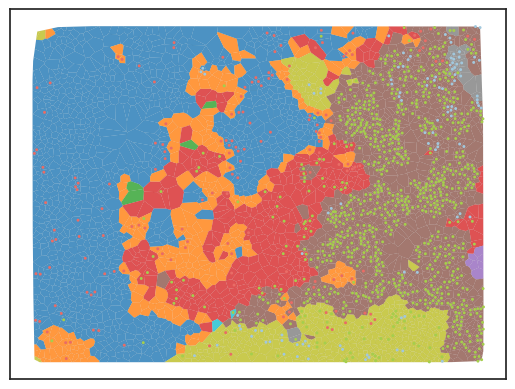

In [44]:
sm.pl.voronoi(adata_sub, color_by='RCNs', colors=rcn_colors, imageid='core_imageid',
                  x_coordinate='Y_centroid', y_coordinate='X_centroid', flip_y=False,
                  voronoi_edge_color = 'black', voronoi_line_width = 0.01, voronoi_alpha = 0.8, #figsize=(15, 15),
                  plot_legend=False, legend_size=6,
                  overlay_points='GCLC_VIM',
                  overlay_points_categories=['Tumor.GCLC+VIM+', 'CD206.Macrophages', 'CD4.T.cells'],
                  overlay_points_colors={'Tumor.GCLC+VIM+': '#E96C66', 'CD206.Macrophages': '#A2C8DD','CD4.T.cells': '#A5CE4D'},
                  #saveDir=f'/Users/wenqchen/Desktop/Projects/Auria/Plots/Voronoi/Voronoi_{core_imageid}',
                  #filename=f'Voronoi_{core_imageid}.pdf'
                 )

In [8]:
adata_sub.obs['GCLC_VIM'].unique()

array(['Tumor.GCLC+VIM-', 'Tumor.GCLC-VIM-', 'Tumor.GCLC+VIM+',
       'CD68.Macrophages', 'VIM+.Stroma', 'Treg', 'CD4.T.cells',
       'Tumor.GCLC-VIM+', 'Other.Stroma', 'Other.Immune', 'SMA+.Stroma',
       'CD206.Macrophages', 'CD8.T.cells'], dtype=object)

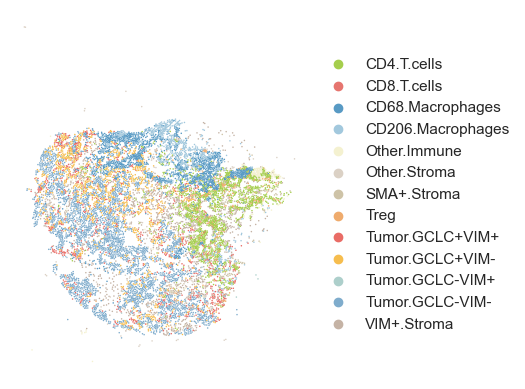

In [20]:
sc.pl.spatial(adata_sub, color='GCLC_VIM', spot_size=15, title='',
              frameon=False, show=True, palette=celltype_colors, #save='GCLC_VIM_INF2.pdf'
              )

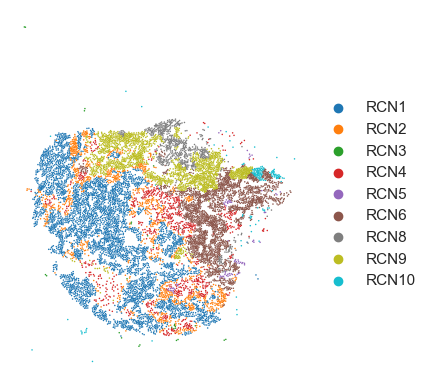

In [19]:
sc.pl.spatial(adata_sub, color='RCNs', spot_size=15, title='',
              frameon=False, show=True, palette=rcn_colors, #save='GCLC_VIM_INF2.pdf'
              )